# Step-by-step demo of NEDAS using the vort2d model



## System setup (optional)

In Google Colab, set `to_install = True` and run this cell to install the environment.
You may need to restart the kernel after this, but you only need to run this once.

In the docker image ``myying/nedas-tutorials`` the environment is installed ready, you can skip this part.


In [1]:
to_install = False

if to_install:
    # 1. Install the latest version of NEDAS on develop branch
    %cd ~
    %rm -rf NEDAS
    !git clone https://github.com/nansencenter/NEDAS.git
    %cd NEDAS
    %pip install .
    
    # 2. Install additional dependencies
    # numba provides JIT compilation of python function to speed it up during runtime
    %pip install numba
    # cmocean provides better colormaps for visualization
    %pip install cmocean
    # ipython widgets for interactive plots
    %pip install ipywidgets
    
    # 3. Clone the tutorial repo too
    %mkdir ~/work
    %cd ~/work
    %rm -rf NEDAS_tutorials
    !git clone https://github.com/myying/NEDAS_tutorials.git
    %cd ~/work/NEDAS_tutorials


## Initialization

In [1]:
# load utility modules for the notebook
import copy
import numpy as np
import matplotlib.pyplot as plt
import cmocean
import ipywidgets as widgets
from IPython.display import Image, display, clear_output

# key NEDAS modules
from NEDAS.config import Config
from NEDAS.schemes import get_scheme
from NEDAS.core import State, Obs
from NEDAS.assim_tools.assimilators import get_assimilator

# some utility funcs for the vort2d case
from vort2d.utils import get_time_series, get_truth, get_model_ens
from vort2d.diagnostics import rmse, sprd, grid_to_spec, variance_spec, ens_corr

# some graphics routines
from vort2d.graphics import *

To initialize NEDAS we just need a YAML file `vort2d/config.yml` that contains all the settings for an experiment.

See [Configuration file](https://nedas.readthedocs.io/en/latest/config_file.html) documentation for more details.

In command line, you can run the experiment with `python -m NEDAS -c vort2d/config.yml`

Here we setup the `config` object in an interactive environment:

In [2]:
# load configuration YAML file
# additional kwargs will overwrite the values in the file
config = Config(config_file="vort2d/config.yml", nproc=1, debug=False)

# you can also change values after the initialization, like this
# config.nproc = 1
# config.debug = False

# to check all the config parameters
# config.__dict__

In [3]:
# Once you are happy with the configuration,
# you can initialize the main Scheme object by
scheme = get_scheme(config)

## The verifying truth

We will run an Observing System Simulation Experiment (OSSE) for the vort2d model.

First step is to generate a "verifying truth", which will be used both for generating synthetic observations and for verification of the results. The `prepare_truth` step calls `model.generate_truth` methods, which define how truth run is created for each model.

In [20]:
%rm -rf vort2d/work/truth

# set time to the start of the experiment
scheme.c.time = config.time_start

# run the model from time_start to time_end and save results
# in offline IO mode, the truth states are saved under model.truth_dir (vort2d/work/truth/*nc files)
scheme.run_step('prepare_truth')


Running prepare_truth step:                                                                                                                                                                                                                                                                                
├── Generate vort2d truth ─────────────────────── ✅     6.94s                                                                                                                                                                                                                                                                        
✅     6.94s                                                                                                                                                                                                                                                                                                



In [4]:
# collect the truth states for each time step
truth_state = get_time_series(scheme.c, get_truth)

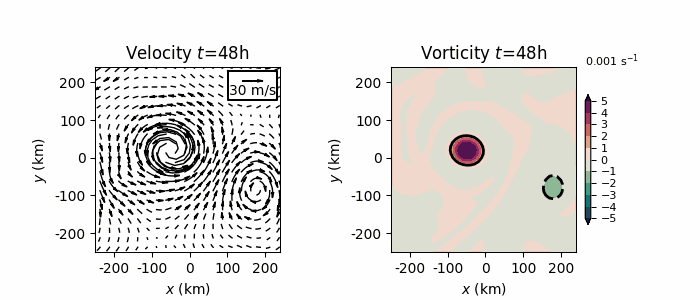

In [9]:
# visualize the truth state over time
casename = 'truth'
plotname = 'state'

# loop over time index and make plot
hours = get_hours(scheme.c)
t_ids = get_time_id_for_plot(scheme.c)
for i, n in enumerate(t_ids):
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))
    plot_velocity_map(ax[0], scheme.c, hours[n], truth_state[n], color='k')
    plot_vorticity_map(fig, ax[1], scheme.c, hours[n], truth_state[n], colorbar=True)
    plt.savefig(f"vort2d/work/plots/{casename}_{plotname}_{i+1:02}.png")
    plt.close()

# make an animation
make_animation(scheme.c, casename, plotname)
display(Image(filename=f'vort2d/{casename}_{plotname}_animation.gif'))

## Ensemble generation

Now we generate an initial ensemble by perturbing initial conditions

The ``model.generate_init_ensemble`` method describes how the initial conditions shall be perturbed. For the vort2d model case, we randomly place the main vortex in the domain and background flow with random additive noises.

In [11]:
%rm -rf vort2d/work/init_ens

In [12]:
scheme.c.time = config.time_start

In [13]:
# this calls the model.generate_init_ensemble and save to files (vort2d/work/init_ens/*nc)
scheme.run_step('prepare_init_ensemble')

# this prepares the first analysis cycle
scheme.run_step('preprocess')


Running prepare_init_ensemble step:                                                                                                                                                                                                                                                                        
├── Generate vort2d init ensemble ─────────────── ✅     4.67s (all 16 jobs done)                                                                                                                                                                                                                                                     
✅     4.67s                                                                                                                                                                                                                                                                                                


Running preprocess step:                                               

In [14]:
init_ens = get_model_ens(scheme.c, config.time_start)

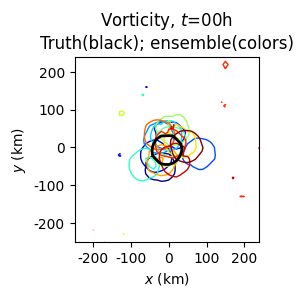

In [15]:
# visualize the ensemble using a spaghetti plot
# a vorticity contour is highlighted in black in the truth state
# for each ensemble member, the same contour is shown in a different color
fig, ax = plt.subplots(1, 1, figsize=(3,3))
hours = get_hours(scheme.c)

n = 0 # initial time step
plot_vorticity_spaghetti(fig, ax, scheme.c, hours[n], truth_state[n], init_ens)

## Data assimilation

In this section, we show how a scalar observation (u component of a single wind obs) impacts the prior state (u, v wind fields) after DA. We will see how the "observation prior" is compared to the observation to derive analysis increment in the observation space; how the scalar observation is correlated with model state variables, and this correlation is utilized to correct all state variables according to the analysis increment with respect to this observation.

Then a full observation network (multiple random points sampled from the model domain) results in a posterior ensemble with reduced error in the ensemble mean and reduced ensemble spread indicating increased accuracy.

### Generate a single wind observation

In [5]:
# to help visualize the error distribution, we will use a larger ensemble in this section
config.nens = 200

# a single wind observation placed near the main vortex
config.obs_def[0]['nobs'] = 1
config.obs_def[0]['err']['std'] = 5  #m/s
config.obs_def[0]['hroi'] = 150_000  #meter
config.dataset_def['vort2d']['network_type'] = 'targeted'
config.dataset_def['vort2d']['obs_range'] = 50_000

# we will use the EAKF to only assimilate the first scalar obs (u-component wind)
config.assimilator_def['type'] = 'EAKF'

scheme = get_scheme(config)

In [17]:
# generate the initial ensemble and save to first analysis cycle
scheme.run_step('prepare_init_ensemble')
scheme.run_step('preprocess')


Running prepare_init_ensemble step:                                                                                                                                                                                                                                                                        
├── Generate vort2d init ensemble ─────────────── ✅     9.53s (all 200 jobs done)                                                                                                                                                                                                                                                    
✅     9.66s                                                                                                                                                                                                                                                                                                


Running preprocess step:                                               

In [6]:
# make sure the analysis directory exists
%mkdir -p vort2d/work/cycle/200101010000/analysis

# the misc. assimilation tools: localization inflation funcs, transformation, etc.
# we don't go into details here, but they need to be initialized for the assimilator to work properly.
scheme.c.iter = 0
scheme.c.update_assim_tools()

In [7]:
# initialize the state object, which holds the prior ensemble in 'fields_prior' dict
scheme.c.state = State(scheme.c)
scheme.c.logger('Prepare state')(scheme.c.state.prepare_state)(scheme.c)


Prepare state:                                                                                                                                                                                                                                                                                             
├── Collect prior fields ──────────────────────── ✅     2.62s                                                                                                                                                                                                                                                                        
├── Collect reference z coords ────────────────── ✅     0.03s                                                                                                                                                                                                                                                                        
├── Output prior ensemble members ─────────────

In [8]:
# initialize the obs object, which will hold both the observations and the 'observation prior' (the obs derived from model prior)
scheme.c.obs = Obs(scheme.c)

# generate the synthetic observation, a random location is drawn each time
scheme.c.logger('Prepare obs')(scheme.c.obs.prepare_obs)(scheme.c)
# compute the 'observation prior' from the model ensemble states
scheme.c.logger('Compute obs from prior state')(scheme.c.obs.prepare_obs_from_state)(scheme.c, 'prior')


Prepare obs ───────────────────────────────────── ✅     0.03s                                                                                                                                                                                                                                              

Compute obs from prior state ──────────────────── ✅     0.22s                                                                                                                                                                                                                                                                        


### Visualize the error distribution and correlation

In [9]:
vnames = ['u', 'v']
rec_id = 0
state_ens = np.array([scheme.c.state.fields_prior[m,rec_id] for m in range(config.nens)])

obs_rec_id = 0
obs_ind = 0  # assimilate the first obs
obs_seq = scheme.c.obs.obs_seq[obs_rec_id]
obs_val = obs_seq['obs'][0]  #only the u component will be assimilated
obs_x = obs_seq['x']
obs_y = obs_seq['y']

# ensemble mean state and obs
obs_ens = np.array([scheme.c.obs.obs_prior[m,obs_rec_id][0,obs_ind] for m in range(config.nens)])

# compute correlation
corr = []
for v in range(2):
    corr.append(ens_corr(state_ens[:,v,...], obs_ens))
corr = np.array(corr)

In [14]:
def plot_corr_map(i, j):
    clear_output(wait=True)
    fig, ax = plt.subplots(2, 3, figsize=(12,6))

    # truth and obs velocity on map
    for v in range(2):
        plot_var_on_map(fig, ax[v,0], scheme.c, f'Truth ${vnames[v]}$', truth_state[0][v,...], -50, 50, 10, 'bwr', 'm/s')
        add_obs_marker(ax[v,0], obs_x, obs_y)
        add_state_marker(ax[v,0], grid, i, j)
    
    # correlation map
    for v in range(2):
        plot_var_on_map(fig, ax[v,1], scheme.c, f"Corr(Obs $u$, State ${vnames[v]}$)", corr[v,...], -1, 1, 0.2, cmocean.cm.balance, '')
        add_obs_marker(ax[v,1], obs_x, obs_y)
        add_state_marker(ax[v,1], grid, i, j)
    
    # scatter plot of obs-state relation
    for v in range(2):
        ax[v,2].scatter(obs_ens, state_ens[:,v,j,i], color='c', s=15)
        ax[v,2].plot([obs_val, obs_val], [-50, 50], 'y-', linewidth=3, alpha=0.5)
        ax[v,2].plot([-50, 50], [truth_state[0][v,j,i], truth_state[0][v,j,i]], 'k-', linewidth=0.5)
        ax[v,2].set_xlabel("Obs $u$ (m/s)")
        ax[v,2].set_ylabel(f"State ${vnames[v]}$ (m/s)")
        ax[v,2].set_xlim([-50, 50])
        ax[v,2].set_ylim([-50, 50])
        ax[v,2].set_title(f"$r = {corr[v,j,i]:.2f}$")
        adjust_ax_size(ax[v,2],0.8,0.8,0.05)

    plt.show()

In [ ]:
# interactive ui with sliders for the i,j location of state variable (u, v)
# which will be compared with the observed u variable in a bivariate scatter plot
grid = scheme.c.grid
i, j = 20, 20
i_slider = widgets.IntSlider(value=i, min=0, max=grid.nx-1, description='i:', orientation='horizontal')
j_slider = widgets.IntSlider(value=j, min=0, max=grid.ny-1, description='j:', orientation='vertical')

output_corr = widgets.Output()

def plot(i, j):
    with output_corr:
        plot_corr_map(i, j)

interactive_plot = widgets.interactive_output(plot, {'i': i_slider, 'j': j_slider})

# Layout: vertical j_slider to the left of plot and i_slider above
ui = widgets.VBox([
    i_slider,
    widgets.HBox([
        j_slider,
        output_corr,
    ])
])

display(ui, interactive_plot)

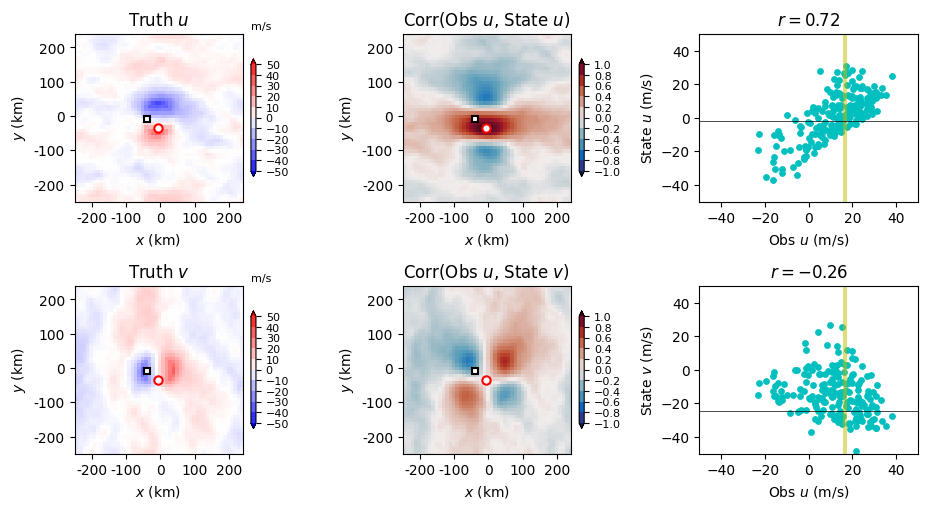

In [16]:
i, j = 21, 24
plot_corr_map(i, j)

### Assimilation algorithm

In this part, we take a deep dive into assimilation algorithm and see what's done using a scalar observation (u component velocity) to update a field of state variables (u component velocity)

Use EAKF and only assimilate one scalar observation at a time

In [17]:
scheme.c.assimilator = get_assimilator(scheme.c)

In [18]:
# detailed steps in scheme.c.assimilator.assimilate
scheme.c.assimilator.partition_grid(scheme.c)
scheme.c.logger('Transpose to ensemble-complete')(scheme.c.assimilator.transpose_to_ensemble_complete)(scheme.c)


Transpose to ensemble-complete:                                                                                                                                                                                                                                                                            
├── Transpose prior state ─────────────────────── ✅     0.03s                                                                                                                                                                                                                                                                        
├── Transpose z coordinates ───────────────────── ✅     0.03s                                                                                                                                                                                                                                                                        
├── Transpose obs sequences ───────────────────

In [19]:
# the core assimilation algorithm
# assimilates c.obs.obs_seq into c.state.state_prior to get c.state.state_post
# detailed steps in self.assimilation_algorithm(c)
scheme.c.state.state_post = copy.deepcopy(scheme.c.state.state_prior)
scheme.c.obs.lobs_post = copy.deepcopy(scheme.c.obs.lobs_prior)

In [20]:
par_id = scheme.c.pid_mem
state_data = scheme.c.state.pack_local_state_data(scheme.c, par_id, scheme.c.state.state_prior, scheme.c.state.state_z)
obs_data = scheme.c.obs.pack_local_obs_data(scheme.c, par_id, scheme.c.obs.lobs, scheme.c.obs.lobs_prior)
obs_list = scheme.c.obs.global_obs_list(scheme.c)

In [21]:
# assimilating the p-th observation in the global_obs_list

def assimilate_one_obs(c, p, state_data, obs_data):
    obs_rec_id, v, owner_pid, i = obs_list[p]

    # compute obs-space increment
    obs_prior = obs_data['obs_prior'][:, i]
    obs_incr = c.assimilator.obs_increment(obs_prior, obs_data['obs'][i], obs_data['err_std'][i])

    # update state:
    state_data['state_prior'] = update_ensemble(state_data['state_prior'], obs_prior, obs_incr)    

    # update obs:
    obs_data['obs_prior'] = update_ensemble(obs_data['obs_prior'], obs_prior, obs_incr)

def update_ensemble(ens_prior, obs_prior, obs_incr) -> np.ndarray:
    nens = ens_prior.shape[0]
    ens_post = ens_prior.copy()

    # obs-space statistics
    obs_prior_mean = np.mean(obs_prior)
    obs_prior_var = np.sum((obs_prior - obs_prior_mean)**2) / (nens-1)

    cov = np.zeros(ens_prior.shape[1:])
    for m in range(nens):
        cov += ens_prior[m, ...] * (obs_prior[m] - obs_prior_mean) / (nens-1)

    reg_factor = cov / obs_prior_var

    # the updated posterior ensemble
    for m in range(nens):
        ens_post[m, ...] = ens_prior[m, ...] +  reg_factor * obs_incr[m]

    return ens_post

In [22]:
# the prior state and obs
rec_id = 0
state_ens_0 = np.array([scheme.c.state.fields_prior[m,rec_id] for m in range(config.nens)])
obs_ens_0 = np.array([scheme.c.obs.obs_prior[m,obs_rec_id][0,obs_ind] for m in range(config.nens)])

In [23]:
# assimilate the scalar obs
assimilate_one_obs(scheme.c, 0, state_data, obs_data)

In [24]:
# convert data back to field complete
scheme.c.state.unpack_local_state_data(scheme.c, par_id, scheme.c.state.state_post, state_data)
scheme.c.obs.unpack_local_obs_data(scheme.c, par_id, scheme.c.obs.lobs, scheme.c.obs.lobs_post, obs_data)
scheme.c.logger('Transpose back to field-complete')(scheme.c.assimilator.transpose_to_field_complete)(scheme.c)


Transpose back to field-complete:                                                                                                                                                                                                                                                                          
├── Tranpose posterior state back ─────────────── ✅     0.03s                                                                                                                                                                                                                                                                        
├── Transpose obs posterior ensemble back ─────── ✅     0.01s                                                                                                                                                                                                                                                                        
✅     0.03s                                    

In [25]:
# the posterior state and obs
state_ens_1 = np.array([scheme.c.state.fields_post[m,rec_id] for m in range(config.nens)])
obs_ens_1 = np.array([scheme.c.obs.obs_post[m,obs_rec_id][0,obs_ind] for m in range(config.nens)])

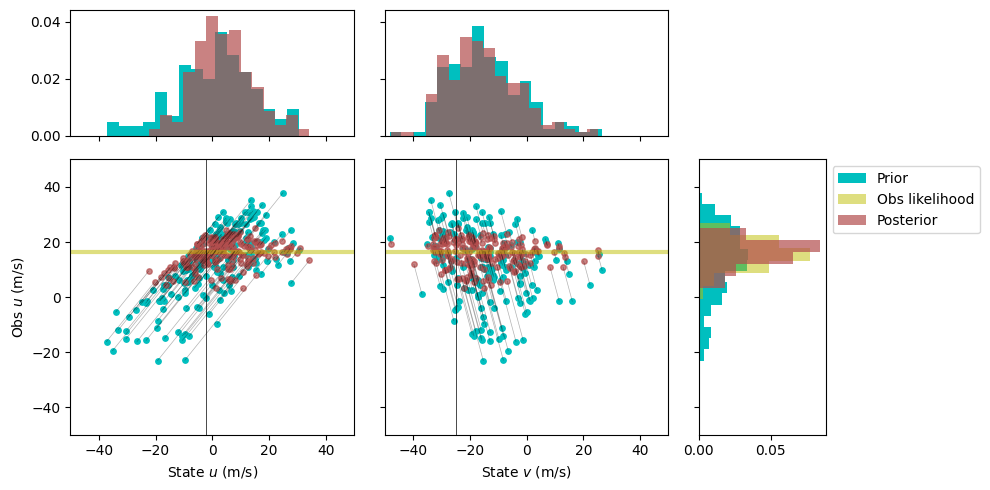

In [28]:
# bivariate scatter plots between the observation u wind (y axis) and state u (x axis on left panel) and state v (x axis on right panel)
# truth value is indicated by thin black lines
# obs value is indicated by a yellow horizontal line
# the histogram appended to the right is showing obs-space Bayesian update (from prior distribution to posterior, with obs likelihood)
# the top histograms show the resulting change in error distribution for the two state variables
plot_bivariate_scatter(state_ens_0, state_ens_1, obs_ens_0, obs_ens_1, obs_val, obs_seq['err_std'], config.nens, truth_state, i, j)

### Assimilating a full observation network

In [29]:
config = Config(config_file='vort2d/config.yml')

config.obs_def[0]['nobs'] = 100
config.obs_def[0]['hroi'] = 50_000
config.dataset_def['vort2d']['network_type'] = 'targeted'
config.dataset_def['vort2d']['obs_range'] = 200_000

scheme = get_scheme(config)

In [30]:
scheme.run_step('preprocess')

scheme.c.iter = 0
scheme.c.update_assim_tools()

scheme.c.state = State(scheme.c)
scheme.c.logger('Prepare state')(scheme.c.state.prepare_state)(scheme.c)

scheme.c.obs = Obs(scheme.c)
scheme.c.logger('Prepare obs')(scheme.c.obs.prepare_obs)(scheme.c)
scheme.c.logger('Compute obs from prior state')(scheme.c.obs.prepare_obs_from_state)(scheme.c, 'prior')

scheme.c.assimilator = get_assimilator(scheme.c)
scheme.c.logger('Assimilator')(scheme.c.assimilator.assimilate)(scheme.c)


Running preprocess step:                                                                                                                                                                                                                                                                                   
├── Preprocess vort2d ─────────────────────────── ✅    16.38s (all 16 jobs done)                                                                                                                                                                                                                                                     
✅    16.38s                                                                                                                                                                                                                                                                                                


Prepare state:                                                         

In [31]:
rec_id = 0
obs_rec_id = 0
state_ens_0 = np.array([scheme.c.state.fields_prior[m,rec_id] for m in range(config.nens)])
obs_ens_0 = np.array([scheme.c.obs.obs_prior[m,obs_rec_id][0,:] for m in range(config.nens)])

state_ens_1 = np.array([scheme.c.state.fields_post[m,rec_id] for m in range(config.nens)])
obs_ens_1 = np.array([scheme.c.obs.obs_post[m,obs_rec_id][0,:] for m in range(config.nens)])

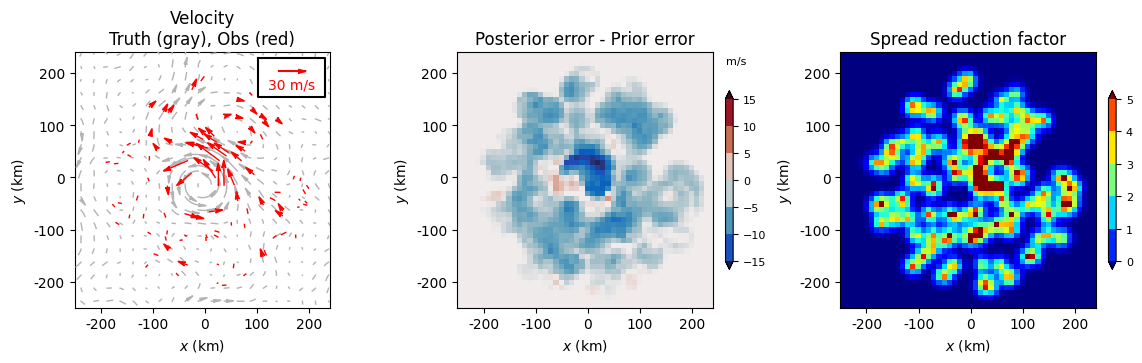

In [32]:
fig, ax = plt.subplots(1,3,figsize=(14,5))

plot_velocity_map(ax[0], scheme.c, 0, truth_state[0,...], showref=False)
obs_seq = scheme.c.obs.obs_seq[obs_rec_id]
plot_velocity_obs(ax[0], scheme.c.grid, obs_seq['obs'], obs_seq['x'], obs_seq['y'])
ax[0].set_title('Velocity\nTruth (gray), Obs (red)')

prior_mean = np.mean(state_ens_0,axis=0)
post_mean = np.mean(state_ens_1,axis=0)
prior_err = np.sqrt(np.mean((prior_mean - truth_state[0])**2, axis=0))
post_err = np.sqrt(np.mean((post_mean - truth_state[0])**2, axis=0))
plot_var_on_map(fig, ax[1], scheme.c, 'Posterior error - Prior error', post_err - prior_err, -15, 15, 5, cmocean.cm.balance, 'm/s')

prior_sprd = np.mean(np.std(state_ens_0, axis=0), axis=0)
post_sprd = np.mean(np.std(state_ens_1, axis=0), axis=0)
post_sprd[np.where(post_sprd==0)] = 1e-10
srf = prior_sprd / post_sprd - 1
plot_var_on_map(fig, ax[2], scheme.c, 'Spread reduction factor', srf, 0, 5, 1, 'jet', '')


## Running DA experiments

Running the full cycling DA experiment from `time_start` to `time_end`

In [25]:
cases_output = {}

### Define cases

Below listed a few cases to play with, choose one and go to the next step

In [27]:
casename = 'assimGlobal'
config = Config(config_file='vort2d/config.yml')

In [ ]:
casename = 'assimGlobalDense'
config = Config(config_file='vort2d/config.yml')
config.obs_def[0]['nobs'] = 4000

In [35]:
casename = 'assimGlobalLessFreq'
config = Config(config_file='vort2d/config.yml', cycle_period=12)

In [17]:
casename = 'assimGlobalSmallEns'
config = Config(config_file='vort2d/config.yml', nens=6)
config.obs_def[0]['hroi'] = 30000.0

In [ ]:
casename = 'assimGlobalAdaptiveInflation'
config = Config(config_file='vort2d/config.yml', nens=6)
config.inflation_def['adaptive'] = True

In [54]:
# a different obs network, only with targeted obs near the strongest cyclonic vortex
casename = 'assimTargeted'
config = Config(config_file='vort2d/config.yml')
config.obs_def[0]['nobs'] = 300
config.dataset_def['vort2d']['network_type'] = 'targeted'
config.dataset_def['vort2d']['obs_range'] = 50_000

In [18]:
# A free ensemble forecast without DA
casename = 'freeRun'
config = Config(config_file='vort2d/config.yml', run_analysis=False)

### Run the case and collect data

In [36]:
scheme = get_scheme(config)

In [37]:
# clear previous results
%rm -rf vort2d/work/cycle

In [38]:
config.quiet = True

In [39]:
scheme()

In [40]:
truth_state = get_time_series(scheme.c, get_truth)
ens_state = get_time_series(scheme.c, get_model_ens)

# compute rmse and ensemble spread
rmse_ts = rmse(ens_state, truth_state)
sprd_ts = sprd(ens_state)
wn, truth_spec = grid_to_spec(truth_state)
_,  err_spec  = grid_to_spec(np.mean(ens_state, axis=1) - truth_state)
_, sprd_spec  = variance_spec(ens_state)

# save to dict for comparison later
if casename not in cases_output:
    cases_output[casename] = {
        'hours':get_hours(scheme.c),
        'rmse_ts':rmse_ts,
        'sprd_ts':sprd_ts,
        'err_spec':err_spec,
        'sprd_spec':sprd_spec,
        'wn':wn,
        'truth_spec':truth_spec,
    }

### Diagnostic plots

In [41]:
plotname = 'diag'

Case:  assimGlobal


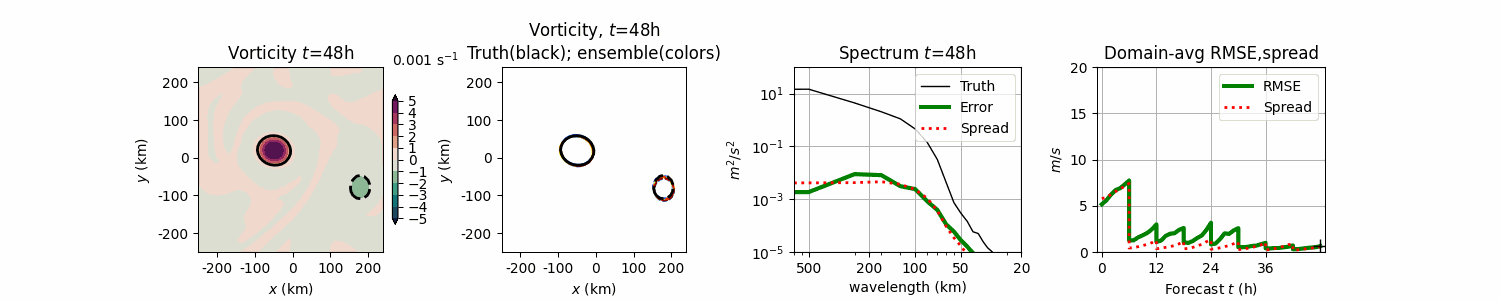

In [34]:
%mkdir -p vort2d/work/plots

# loop over time index and make plot
hours = get_hours(scheme.c)
t_ids = get_time_id_for_plot(scheme.c)
for i, n in enumerate(t_ids):
    fig, ax = plt.subplots(1, 4, figsize=(15, 3))

    # panel 1: truth vorticity with highlighted contours in black
    plot_vorticity_map(fig, ax[0], scheme.c, hours[n], truth_state[n,...], colorbar=True)

    # panel 2: ensemble spaghetti of the highlighted contours
    plot_vorticity_spaghetti(fig, ax[1], scheme.c, hours[n], truth_state[n,...], ens_state[n,...])

    # panel 3: spectra of RMSE and ens spread compared to truth
    ax[2].loglog(wn, np.mean(truth_spec[n,...], axis=0), color='k', linewidth=1, label='Truth')
    ax[2].loglog(wn, np.mean(err_spec[n,...], axis=0), color='g', linewidth=3, label='Error')
    ax[2].loglog(wn, np.mean(sprd_spec[n,...], axis=0), color='r', linestyle=':', linewidth=2, label='Spread')
    ax[2].legend(loc='upper right')
    adjust_spec_ax(ax[2], scheme.c.grid.Lx, hours[n])

    # panel 4: Sawtooth time series of RMSE and ens spread
    ax[3].plot(hours[0:n+1], rmse_ts[0:n+1], color='g', linewidth=3, label='RMSE')
    ax[3].plot(hours[0:n+1], sprd_ts[0:n+1], color='r', linestyle=':', linewidth=2, label='Spread')
    ax[3].plot(hours[n], rmse_ts[n], color='k', marker='+', markersize=10)
    ax[3].legend(loc='upper right')
    adjust_ts_ax(ax[3], hours)

    plt.savefig(f"vort2d/work/plots/{casename}_{plotname}_{i+1:02}.png")
    plt.close()

make_animation(scheme.c, casename, plotname)
print('Case: ', casename)
display(Image(filename=f'vort2d/{casename}_{plotname}_animation.gif'))

In [ ]:
# or, to view the plots in an interactive ui with a time slider
ui = animation_ui(scheme.c, casename, plotname)
display(ui)

### Compare cases

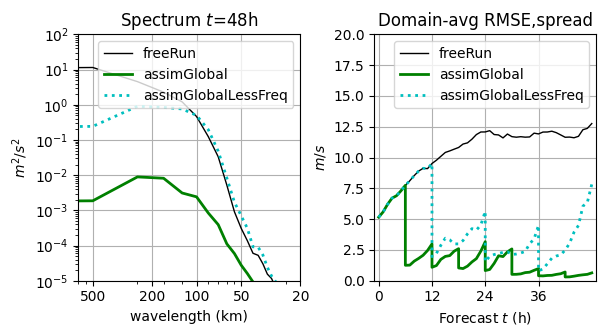

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(7,4))

cases_to_compare = ['freeRun', 'assimGlobal', 'assimGlobalLessFreq']
colors = ['k', 'g', 'c']
styles = ['-', '-', ':']
widths = [1, 2, 2]

for i,casename in enumerate(cases_to_compare):
    if casename not in cases_output:
        raise KeyError(f"Case '{casename}' not run yet!")

    # panel 1: comparison of error spectrum at last time step
    wn = cases_output[casename]['wn']
    err_spec = np.mean(cases_output[casename]['err_spec'][-1,...], axis=0)
    ax[0].loglog(wn, err_spec, color=colors[i], linestyle=styles[i], linewidth=widths[i], label=casename)

    # panel 2: comparison of error time series
    hours = cases_output[casename]['hours']
    rmse_ts = cases_output[casename]['rmse_ts']
    ax[1].plot(hours, rmse_ts, color=colors[i], linestyle=styles[i], linewidth=widths[i], label=casename)

ax[0].legend(loc='upper right')
adjust_spec_ax(ax[0], scheme.c.grid.Lx, hours[-1])
ax[1].legend(loc='upper right')
adjust_ts_ax(ax[1], hours)
